In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models.segmentation import deeplabv3_resnet50, deeplabv3_resnet101
import torch.nn.functional as F

import numpy as np
import cv2
import os
import glob
from PIL import Image
import json
from datetime import datetime
from tqdm import tqdm
from sklearn.metrics import jaccard_score, precision_score, recall_score, f1_score


def setup_google_drive():
    """Setup Google Drive access in Colab"""
    try:
        from google.colab import drive
        print("Mounting Google Drive...")
        drive.mount('/content/drive')
        if os.path.exists('/content/drive/MyDrive'):
            print("Google Drive mounted successfully!")
            return True
        else:
            print("Failed to mount Google Drive")
            return False
    except ImportError:
        print("Not running in Google Colab - Google Drive mounting skipped")
        return False
    except Exception as e:
        print(f"Error mounting Google Drive: {e}")
        return False

def create_model_directory():
    """Create directory for the latest model"""
    model_dir = "/content/drive/MyDrive/latest_segmentation_model"
    os.makedirs(model_dir, exist_ok=True)
    print(f"Created/verified directory: {model_dir}")
    return model_dir


# DATASET CLASS - MODIFIED FOR NON_TUMOR

class BrainTumorDatasetWithNonTumor(Dataset):
    """Dataset class that includes non-tumor images"""

    def __init__(self, dataset_folder, transform=None, augment=False):
        self.dataset_folder = dataset_folder
        self.transform = transform
        self.augment = augment
        self.samples = []

        # Load tumor classes (with masks)
        tumor_classes = ['glioma', 'meningioma', 'pituitary']

        for class_name in tumor_classes:
            class_folder = os.path.join(dataset_folder, class_name)
            if not os.path.exists(class_folder):
                continue

            image_files = glob.glob(os.path.join(class_folder, "*_image.png"))

            for image_path in image_files:
                base_name = os.path.basename(image_path).replace('_image.png', '')
                mask_path = os.path.join(class_folder, f"{base_name}_mask.png")

                if os.path.exists(mask_path):
                    self.samples.append({
                        'image_path': image_path,
                        'mask_path': mask_path,
                        'class_name': class_name,
                        'sample_id': base_name,
                        'has_tumor': True
                    })

        # Load non-tumor images (JPG, no masks)
        non_tumor_folder = os.path.join(dataset_folder, 'non_tumor')
        if os.path.exists(non_tumor_folder):
            non_tumor_files = glob.glob(os.path.join(non_tumor_folder, "*.jpg"))
            non_tumor_files += glob.glob(os.path.join(non_tumor_folder, "*.jpeg"))
            non_tumor_files += glob.glob(os.path.join(non_tumor_folder, "*.JPG"))

            print(f"Found {len(non_tumor_files)} non-tumor images")

            for image_path in non_tumor_files:
                base_name = os.path.basename(image_path).rsplit('.', 1)[0]
                self.samples.append({
                    'image_path': image_path,
                    'mask_path': None,  # No mask for non-tumor
                    'class_name': 'non_tumor',
                    'sample_id': base_name,
                    'has_tumor': False
                })

        print(f"Total samples loaded: {len(self.samples)}")
        tumor_count = sum(1 for s in self.samples if s['has_tumor'])
        print(f"   - With tumor: {tumor_count}")
        print(f"   - Without tumor: {len(self.samples) - tumor_count}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Load image
        image = cv2.imread(sample['image_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load or create mask
        if sample['has_tumor']:
            # Load actual mask
            mask = cv2.imread(sample['mask_path'], cv2.IMREAD_GRAYSCALE)
            mask = (mask > 0).astype(np.uint8)
        else:
            # Create empty mask for non-tumor images
            h, w = image.shape[:2]
            mask = np.zeros((h, w), dtype=np.uint8)

        # Apply augmentation if enabled
        if self.augment and np.random.random() > 0.5:
            image, mask = self.apply_augmentation(image, mask)

        # Apply transforms
        if self.transform:
            image = Image.fromarray(image)
            image = self.transform(image)
            mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
            mask = torch.from_numpy(mask).long()

        return {
            'image': image,
            'mask': mask,
            'sample_info': {
                'class_name': sample['class_name'],
                'sample_id': sample['sample_id'],
                'has_tumor': sample['has_tumor']
            }
        }

    def apply_augmentation(self, image, mask):
        """Apply data augmentation"""
        if np.random.random() > 0.5:
            image = cv2.flip(image, 1)
            mask = cv2.flip(mask, 1)

        if np.random.random() > 0.7:
            angle = np.random.uniform(-15, 15)
            h, w = image.shape[:2]
            center = (w // 2, h // 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            image = cv2.warpAffine(image, M, (w, h))
            mask = cv2.warpAffine(mask, M, (w, h), flags=cv2.INTER_NEAREST)

        if np.random.random() > 0.6:
            alpha = np.random.uniform(0.8, 1.2)
            beta = np.random.uniform(-20, 20)
            image = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)

        return image, mask

def create_compatible_deeplabv3(backbone='resnet50', num_classes=2, pretrained=True):
    """Create DeepLabV3 model"""
    if pretrained:
        print("Loading pretrained DeepLabV3 model...")
        try:
            if backbone == 'resnet50':
                model = deeplabv3_resnet50(weights='DeepLabV3_ResNet50_Weights.DEFAULT', aux_loss=True)
            else:
                model = deeplabv3_resnet101(weights='DeepLabV3_ResNet101_Weights.DEFAULT', aux_loss=True)

            model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)

            original_forward = model.forward
            def new_forward(x):
                result = original_forward(x)
                if isinstance(result, dict):
                    return {'out': result['out']}
                else:
                    return {'out': result}
            model.forward = new_forward
            print("Pretrained model loaded successfully!")

        except Exception as e:
            print(f"Pretrained loading failed, creating without pretrained weights...")
            if backbone == 'resnet50':
                model = deeplabv3_resnet50(weights=None, num_classes=num_classes, aux_loss=False)
            else:
                model = deeplabv3_resnet101(weights=None, num_classes=num_classes, aux_loss=False)
    else:
        if backbone == 'resnet50':
            model = deeplabv3_resnet50(weights=None, num_classes=num_classes, aux_loss=False)
        else:
            model = deeplabv3_resnet101(weights=None, num_classes=num_classes, aux_loss=False)

    return model


class DeepLabV3MinimalSave:
    """DeepLabV3 with minimal saving - only model + JSON"""

    def __init__(self, backbone='resnet50', num_classes=2, pretrained=True, save_dir=None):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.num_classes = num_classes
        self.save_dir = save_dir

        self.model = create_compatible_deeplabv3(backbone, num_classes, pretrained)
        self.model = self.model.to(self.device)

        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=1e-4, weight_decay=1e-4)
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', patience=5, factor=0.5
        )

        self.train_losses = []
        self.val_losses = []
        self.val_metrics = []
        self.session_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

        print(f"Training session: {self.session_timestamp}")
        print(f"Save directory: {self.save_dir}")

    def dice_loss(self, pred, target, smooth=1):
        """Dice loss"""
        pred = torch.softmax(pred, dim=1)
        pred = pred[:, 1, :, :]
        target = target.float()

        intersection = (pred * target).sum(dim=(1, 2))
        union = pred.sum(dim=(1, 2)) + target.sum(dim=(1, 2))

        dice = (2. * intersection + smooth) / (union + smooth)
        return 1 - dice.mean()

    def combined_loss(self, pred, target):
        """Combined loss"""
        ce_loss = self.criterion(pred, target)
        dice_loss = self.dice_loss(pred, target)
        return ce_loss + dice_loss

    def train_epoch(self, train_loader):
        """Train one epoch"""
        self.model.train()
        total_loss = 0

        progress_bar = tqdm(train_loader, desc="Training")

        for batch in progress_bar:
            images = batch['image'].to(self.device)
            masks = batch['mask'].to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            if isinstance(outputs, dict):
                main_output = outputs['out']
            else:
                main_output = outputs

            loss = self.combined_loss(main_output, masks)
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()
            progress_bar.set_postfix({'loss': loss.item()})

        return total_loss / len(train_loader)

    def validate_epoch(self, val_loader):
        """Validate one epoch"""
        self.model.eval()
        total_loss = 0
        all_predictions = []
        all_targets = []

        with torch.no_grad():
            progress_bar = tqdm(val_loader, desc="Validation")

            for batch in progress_bar:
                images = batch['image'].to(self.device)
                masks = batch['mask'].to(self.device)

                outputs = self.model(images)

                if isinstance(outputs, dict):
                    main_output = outputs['out']
                else:
                    main_output = outputs

                loss = self.combined_loss(main_output, masks)
                total_loss += loss.item()

                preds = torch.argmax(main_output, dim=1)
                all_predictions.extend(preds.cpu().numpy().flatten())
                all_targets.extend(masks.cpu().numpy().flatten())

                progress_bar.set_postfix({'loss': loss.item()})

        avg_loss = total_loss / len(val_loader)
        metrics = self.calculate_metrics(all_predictions, all_targets)

        return avg_loss, metrics

    def calculate_metrics(self, predictions, targets):
        """Calculate metrics"""
        pred_binary = np.array(predictions) > 0
        target_binary = np.array(targets) > 0

        metrics = {
            'dice_score': self.dice_coefficient(pred_binary, target_binary),
            'iou_score': jaccard_score(target_binary, pred_binary, average='binary'),
            'precision': precision_score(target_binary, pred_binary, average='binary', zero_division=0),
            'recall': recall_score(target_binary, pred_binary, average='binary', zero_division=0),
            'f1_score': f1_score(target_binary, pred_binary, average='binary', zero_division=0)
        }

        return metrics

    def dice_coefficient(self, pred, target, smooth=1):
        """Dice coefficient"""
        intersection = np.sum(pred * target)
        union = np.sum(pred) + np.sum(target)
        dice = (2. * intersection + smooth) / (union + smooth)
        return dice

    def train(self, train_loader, val_loader, test_loader, num_epochs=50):
        """Train the model - MINIMAL SAVING"""
        best_dice = 0
        best_epoch = 0

        print(f"Training on device: {self.device}")
        print(f"Model parameters: {sum(p.numel() for p in self.model.parameters()):,}")

        # Test model
        print("Testing model architecture...")
        self.model.eval()
        with torch.no_grad():
            test_input = torch.randn(2, 3, 256, 256).to(self.device)
            test_output = self.model(test_input)['out']
            print(f"Model test successful! Output shape: {test_output.shape}")

        for epoch in range(num_epochs):
            print(f"\nEpoch {epoch+1}/{num_epochs}")
            print("-" * 50)

            train_loss = self.train_epoch(train_loader)
            self.train_losses.append(train_loss)

            val_loss, val_metrics = self.validate_epoch(val_loader)
            self.val_losses.append(val_loss)
            self.val_metrics.append(val_metrics)

            self.scheduler.step(val_loss)

            print(f"Train Loss: {train_loss:.4f}")
            print(f"Val Loss: {val_loss:.4f}")
            print(f"Val Dice: {val_metrics['dice_score']:.4f}")
            print(f"Val IoU: {val_metrics['iou_score']:.4f}")
            print(f"Val F1: {val_metrics['f1_score']:.4f}")

            # Save best model (MINIMAL)
            if val_metrics['dice_score'] > best_dice:
                best_dice = val_metrics['dice_score']
                best_epoch = epoch

                if self.save_dir:
                    model_path = os.path.join(self.save_dir, 'best_model.pth')

                    torch.save({
                        'epoch': epoch,
                        'model_state_dict': self.model.state_dict(),
                        'optimizer_state_dict': self.optimizer.state_dict(),
                        'val_dice': best_dice,
                        'session_timestamp': self.session_timestamp
                    }, model_path)

                    print(f"Best model saved (Dice: {best_dice:.4f})")

        print(f"\nTraining completed! Best Dice: {best_dice:.4f} at epoch {best_epoch+1}")

        # Evaluate on test set
        print("\n" + "=" * 50)
        print("EVALUATING ON TEST SET")
        print("=" * 50)
        test_loss, test_metrics = self.validate_epoch(test_loader)

        print(f"\nTest Results:")
        print(f"Test Loss: {test_loss:.4f}")
        print(f"Test Dice: {test_metrics['dice_score']:.4f}")
        print(f"Test IoU: {test_metrics['iou_score']:.4f}")
        print(f"Test Precision: {test_metrics['precision']:.4f}")
        print(f"Test Recall: {test_metrics['recall']:.4f}")
        print(f"Test F1: {test_metrics['f1_score']:.4f}")

        # Save final JSON summary with test results
        if self.save_dir:
            self.save_training_summary(test_metrics, test_loss)

    def save_training_summary(self, test_metrics, test_loss):
        """Save only a JSON summary with test results"""
        summary = {
            'session_timestamp': self.session_timestamp,
            'training_completed': datetime.now().isoformat(),
            'device': str(self.device),
            'total_epochs': len(self.train_losses),
            'final_train_loss': self.train_losses[-1] if self.train_losses else None,
            'final_val_loss': self.val_losses[-1] if self.val_losses else None,
            'best_validation_metrics': {
                'dice_score': max([m['dice_score'] for m in self.val_metrics]) if self.val_metrics else 0,
                'iou_score': max([m['iou_score'] for m in self.val_metrics]) if self.val_metrics else 0,
                'f1_score': max([m['f1_score'] for m in self.val_metrics]) if self.val_metrics else 0
            },
            'test_results': {
                'test_loss': test_loss,
                'dice_score': test_metrics['dice_score'],
                'iou_score': test_metrics['iou_score'],
                'precision': test_metrics['precision'],
                'recall': test_metrics['recall'],
                'f1_score': test_metrics['f1_score']
            },
            'training_history': {
                'train_losses': self.train_losses,
                'val_losses': self.val_losses,
                'val_metrics': self.val_metrics
            }
        }

        json_path = os.path.join(self.save_dir, 'training_summary.json')
        with open(json_path, 'w') as f:
            json.dump(summary, f, indent=2)

        print(f"Training summary saved: {json_path}")

# =====================================================
# MAIN TRAINING FUNCTION
# =====================================================

def train_with_nontumor():
    """Train model with non-tumor images - MINIMAL SAVE"""

    print("TRAINING DEEPLABV3 WITH NON-TUMOR IMAGES")
    print("=" * 60)

    # Setup Google Drive
    if not setup_google_drive():
        print("Google Drive setup failed")
        return None

    # Create save directory
    save_dir = create_model_directory()

    # Dataset path
    dataset_folder = "/content/drive/MyDrive/Brain_Dataset"

    if not os.path.exists(dataset_folder):
        print(f"Dataset not found at: {dataset_folder}")
        return None

    # Check for non_tumor folder
    non_tumor_path = os.path.join(dataset_folder, 'non_tumor')
    if not os.path.exists(non_tumor_path):
        print(f"Warning: non_tumor folder not found at {non_tumor_path}")
        print("   Continuing with tumor-only data...")

    # Device configuration
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    if device.type == 'cuda':
        print("GPU detected!")
        batch_size = 8
        num_epochs = 50
        num_workers = 2
    else:
        print("CPU detected!")
        batch_size = 2
        num_epochs = 20
        num_workers = 0

    print(f"Configuration: Device={device}, Batch={batch_size}, Epochs={num_epochs}")

    # Create transforms
    train_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Create dataset
    print("Creating dataset...")
    full_dataset = BrainTumorDatasetWithNonTumor(dataset_folder, transform=train_transform, augment=True)

    # Split dataset: 70% train, 15% validation, 15% test
    total_size = len(full_dataset)
    train_size = int(0.7 * total_size)
    val_size = int(0.15 * total_size)
    test_size = total_size - train_size - val_size

    train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
        full_dataset, [train_size, val_size, test_size]
    )

    # Update validation and test dataset transforms
    val_dataset.dataset.transform = val_transform
    val_dataset.dataset.augment = False

    test_dataset.dataset.transform = val_transform
    test_dataset.dataset.augment = False

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                             num_workers=num_workers, pin_memory=(device.type == 'cuda'))
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                           num_workers=num_workers, pin_memory=(device.type == 'cuda'))
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=(device.type == 'cuda'))

    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")

    # Initialize model
    print("Initializing DeepLabV3 model...")
    model = DeepLabV3MinimalSave(backbone='resnet50', num_classes=2, pretrained=True, save_dir=save_dir)

    # Train
    print("Starting training...")
    model.train(train_loader, val_loader, test_loader, num_epochs=num_epochs)

    print("\nTRAINING COMPLETED!")
    print(f"Model saved to: {save_dir}/best_model.pth")
    print(f"Summary saved to: {save_dir}/training_summary.json")

    return model


if __name__ == "__main__":
    model = train_with_nontumor()

TESTING BRAIN TUMOR SEGMENTATION MODEL
Model checkpoint: /content/drive/MyDrive/latest_segmentation_model/best_model.pth
Test image: /content/drive/MyDrive/Brain_Dataset/meningioma/108_image.png

[1/7] Loading model...
   Device: cpu
   Model loaded successfully!
   Trained for 23 epochs

[2/7] Loading image...
   Original image size: 512x512 pixels
   Will be resized to: 256x256 for model input

   Image preprocessed: torch.Size([1, 3, 256, 256])

[3/7] Running prediction...
   Prediction complete!
   Output shape: (256, 256)

[4/7] Resizing to original dimensions...

[5/7] Analysis:
----------------------------------------------------------------------
   Total pixels: 262,144
   Tumor pixels detected: 8,280
   Tumor percentage: 3.16%

   Confidence in tumor region:
      Mean: 0.9791
      Max:  1.0000
      Min:  0.3242

   Confidence distribution across entire image:
      High confidence (>0.8): 7,925 pixels
      Medium confidence (0.5-0.8): 361 pixels
      Any confidence (>0.2

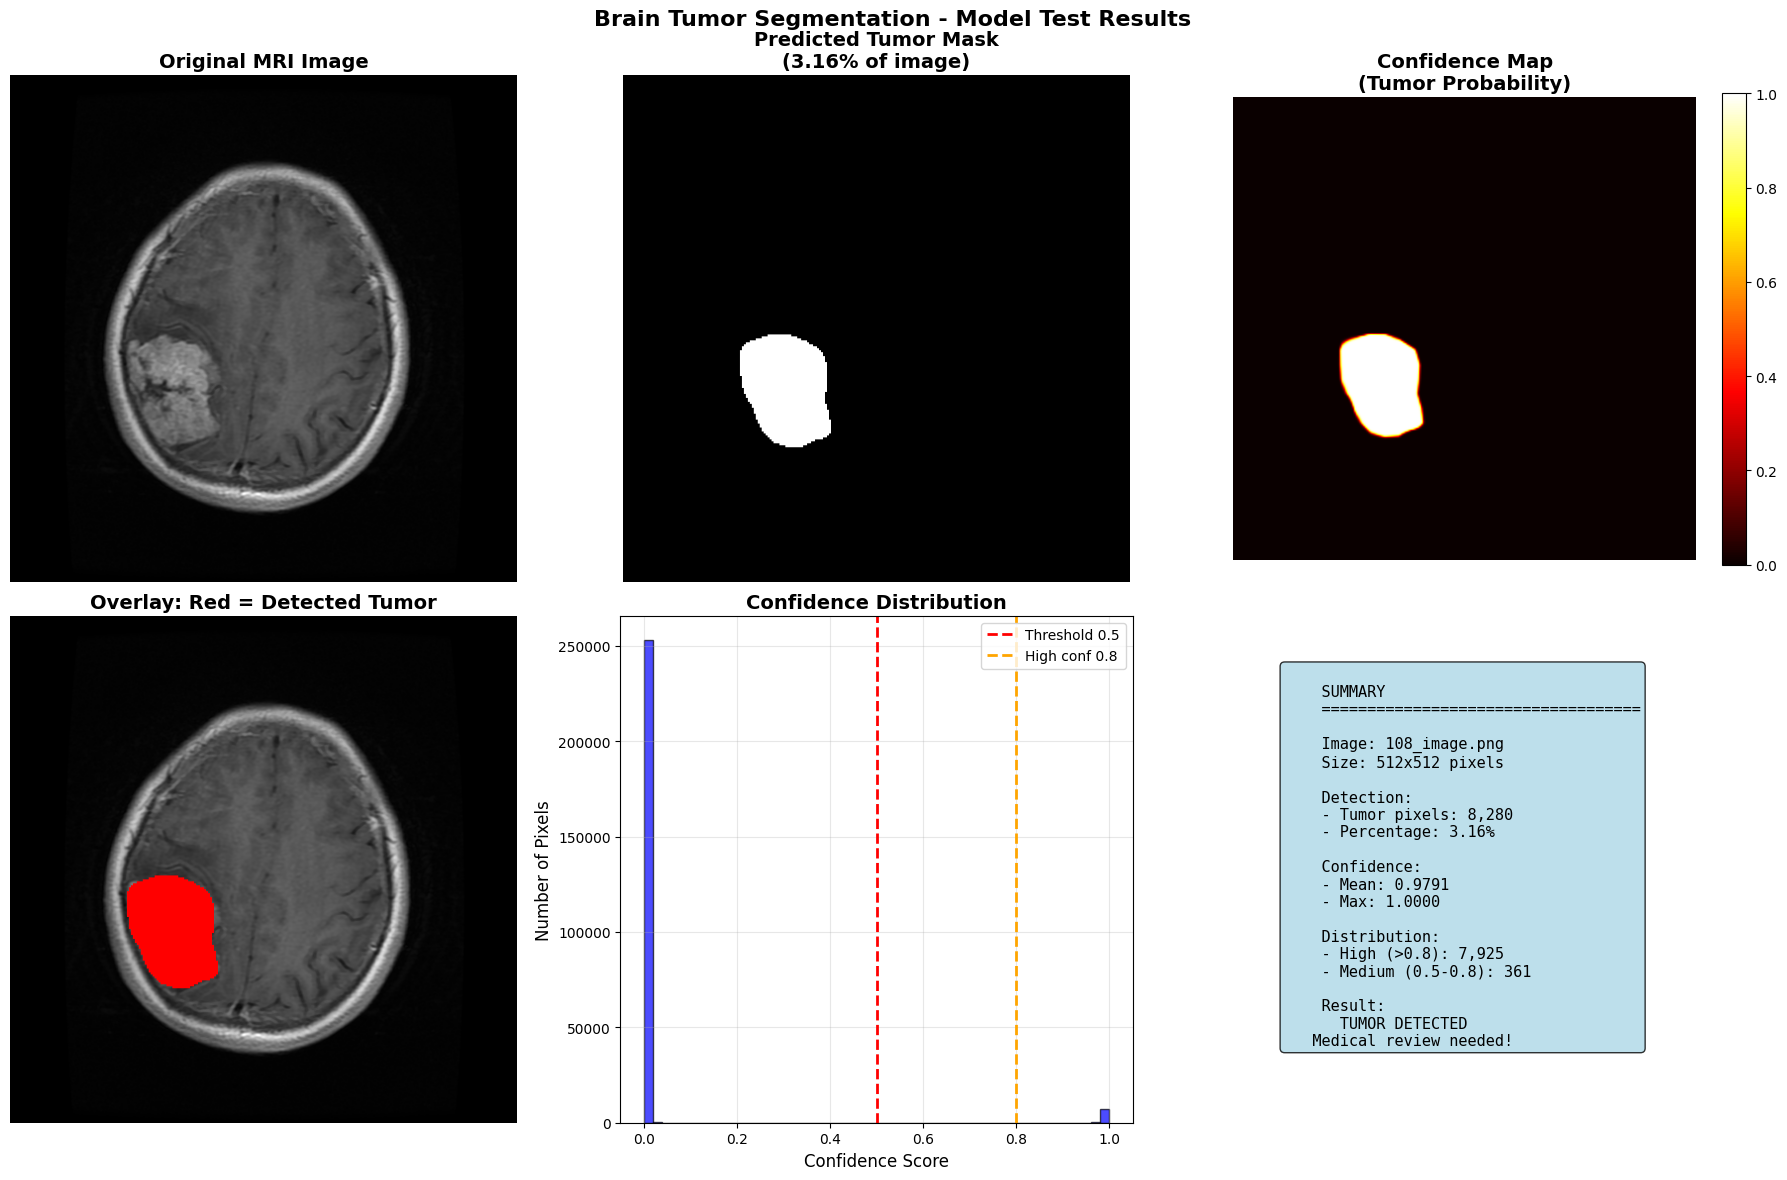

   Mask saved: ./test_results/predicted_mask.png
   Confidence map saved: ./test_results/confidence_map.png

TEST COMPLETED SUCCESSFULLY!

Quick Summary:
   Tumor detected: 3.16%
   Confidence: 0.9791
   Result: TUMOR DETECTED


In [ ]:
import torch
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import os


def quick_test_image(model_path, image_path, save_dir='./test_results'):
    """
    Test  trained model on a single image

    Args:
        model_path: Path to your .pth checkpoint (e.g., 'best_model_20250824_012408.pth')
        image_path: Path to your test image (any size, .jpg/.png)
        save_dir: Where to save results
    """

    # Create output directory
    os.makedirs(save_dir, exist_ok=True)

    print("="*70)
    print("TESTING BRAIN TUMOR SEGMENTATION MODEL")
    print("="*70)
    print(f"Model checkpoint: {model_path}")
    print(f"Test image: {image_path}")
    print()

    # Step 1: Load the model
    print("[1/7] Loading model...")
    from torchvision.models.segmentation import deeplabv3_resnet50

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"   Device: {device}")

    # Create model architecture (must match training)
    model = deeplabv3_resnet50(weights=None, num_classes=2, aux_loss=False)
    model = model.to(device)

    # Load checkpoint
    try:
        checkpoint = torch.load(model_path, map_location=device, weights_only=False)

        # Handle different checkpoint formats
        if 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            state_dict = checkpoint

        # Filter out auxiliary classifier if present
        filtered_state_dict = {k: v for k, v in state_dict.items()
                              if not k.startswith('aux_classifier')}

        model.load_state_dict(filtered_state_dict, strict=False)
        print("   Model loaded successfully!")

        # Print checkpoint info if available
        if 'epoch' in checkpoint:
            print(f"   Trained for {checkpoint['epoch']+1} epochs")
        if 'val_metrics' in checkpoint:
            metrics = checkpoint['val_metrics']
            # Handle both dict and list formats
            if isinstance(metrics, dict):
                print(f"   Validation Dice: {metrics.get('dice_score', 'N/A'):.4f}")
            elif isinstance(metrics, list) and len(metrics) > 0:
                last_metric = metrics[-1]  # Get last epoch metrics
                if isinstance(last_metric, dict):
                    print(f"   Validation Dice: {last_metric.get('dice_score', 'N/A'):.4f}")

    except Exception as e:
        print(f"   Error loading model: {e}")
        return None

    model.eval()
    print()

    # Step 2: Load and preprocess image
    print("[2/7] Loading image...")

    # Load image
    image = cv2.imread(image_path)
    if image is None:
        print(f"   Error: Could not read image from {image_path}")
        return None

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    original_size = image_rgb.shape[:2]

    print(f"   Original image size: {original_size[1]}x{original_size[0]} pixels")
    print(f"   Will be resized to: 256x256 for model input")
    print()

    # Preprocessing transform (same as training)
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    image_pil = Image.fromarray(image_rgb)
    image_tensor = transform(image_pil).unsqueeze(0).to(device)

    print(f"   Image preprocessed: {image_tensor.shape}")
    print()

    # Step 3: Run prediction
    print("[3/7] Running prediction...")

    with torch.no_grad():
        output = model(image_tensor)
        logits = output['out']  # [1, 2, 256, 256]

        # Get probabilities
        probs = F.softmax(logits, dim=1)

        # Get prediction (0 = background, 1 = tumor)
        prediction = torch.argmax(logits, dim=1)[0].cpu().numpy()

        # Get confidence for tumor class
        confidence = probs[0, 1].cpu().numpy()

    print(f"   Prediction complete!")
    print(f"   Output shape: {prediction.shape}")
    print()

    # Step 4: Resize back to original size
    print("[4/7] Resizing to original dimensions...")

    prediction_resized = cv2.resize(
        prediction.astype(np.uint8),
        (original_size[1], original_size[0]),
        interpolation=cv2.INTER_NEAREST
    )

    confidence_resized = cv2.resize(
        confidence,
        (original_size[1], original_size[0]),
        interpolation=cv2.INTER_LINEAR
    )
    print()

    # Step 5: Analyze results
    print("[5/7] Analysis:")
    print("-" * 70)

    tumor_pixels = np.sum(prediction_resized > 0)
    total_pixels = prediction_resized.size
    tumor_percentage = (tumor_pixels / total_pixels) * 100

    print(f"   Total pixels: {total_pixels:,}")
    print(f"   Tumor pixels detected: {tumor_pixels:,}")
    print(f"   Tumor percentage: {tumor_percentage:.2f}%")
    print()

    if tumor_pixels > 0:
        tumor_mask = prediction_resized > 0
        mean_conf = np.mean(confidence_resized[tumor_mask])
        max_conf = np.max(confidence_resized[tumor_mask])
        min_conf = np.min(confidence_resized[tumor_mask])

        print(f"   Confidence in tumor region:")
        print(f"      Mean: {mean_conf:.4f}")
        print(f"      Max:  {max_conf:.4f}")
        print(f"      Min:  {min_conf:.4f}")
    else:
        mean_conf = 0
        max_conf = 0
        print(f"   No tumor detected!")

    print()

    # Overall confidence statistics
    high_conf_pixels = np.sum(confidence_resized > 0.8)
    medium_conf_pixels = np.sum((confidence_resized > 0.5) & (confidence_resized <= 0.8))
    low_conf_pixels = np.sum(confidence_resized > 0.2)

    print(f"   Confidence distribution across entire image:")
    print(f"      High confidence (>0.8): {high_conf_pixels:,} pixels")
    print(f"      Medium confidence (0.5-0.8): {medium_conf_pixels:,} pixels")
    print(f"      Any confidence (>0.2): {low_conf_pixels:,} pixels")
    print()

    # Step 6: Interpretation
    print("[6/7] Interpretation:")
    print("-" * 70)

    # Better thresholds for tumor detection (sensitive to small tumors)
    DETECTION_THRESHOLD_PERCENTAGE = 0.1  # 0.1% of image
    CONFIDENCE_THRESHOLD = 0.7  # 70% confidence

    if tumor_percentage > DETECTION_THRESHOLD_PERCENTAGE and mean_conf > CONFIDENCE_THRESHOLD:
        print("    TUMOR DETECTED")
        print(f"      - Tumor area: {tumor_percentage:.2f}%")
        print(f"      - Confidence: {mean_conf:.4f}")
        print("      - Medical review required!")
        detection_result = "TUMOR DETECTED"
    else:
        print("    NOTHING DETECTED")
        print(f"      - Tumor area: {tumor_percentage:.2f}%")
        print(f"      - Confidence: {mean_conf:.4f}")
        print("      - No significant tumor regions found")
        detection_result = "NOTHING DETECTED"

    print()
    print("="*70)

    # Step 7: Create visualization
    print("[7/7] Creating visualization...")

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # Original image
    axes[0, 0].imshow(image_rgb)
    axes[0, 0].set_title('Original MRI Image', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')

    # Predicted mask
    axes[0, 1].imshow(prediction_resized, cmap='gray')
    axes[0, 1].set_title(f'Predicted Tumor Mask\n({tumor_percentage:.2f}% of image)',
                         fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')

    # Confidence map
    im1 = axes[0, 2].imshow(confidence_resized, cmap='hot', vmin=0, vmax=1)
    axes[0, 2].set_title('Confidence Map\n(Tumor Probability)', fontsize=14, fontweight='bold')
    axes[0, 2].axis('off')
    plt.colorbar(im1, ax=axes[0, 2], fraction=0.046)

    # Overlay on original
    overlay = image_rgb.copy()
    overlay[prediction_resized > 0] = [255, 0, 0]  # Red
    axes[1, 0].imshow(overlay)
    axes[1, 0].set_title('Overlay: Red = Detected Tumor', fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')

    # Confidence histogram
    axes[1, 1].hist(confidence_resized.flatten(), bins=50, color='blue',
                    alpha=0.7, edgecolor='black')
    axes[1, 1].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Threshold 0.5')
    axes[1, 1].axvline(0.8, color='orange', linestyle='--', linewidth=2, label='High conf 0.8')
    axes[1, 1].set_xlabel('Confidence Score', fontsize=12)
    axes[1, 1].set_ylabel('Number of Pixels', fontsize=12)
    axes[1, 1].set_title('Confidence Distribution', fontsize=14, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # Summary text
    axes[1, 2].axis('off')
    summary_text = f"""
    SUMMARY
    {'='*35}

    Image: {os.path.basename(image_path)}
    Size: {original_size[1]}x{original_size[0]} pixels

    Detection:
    - Tumor pixels: {tumor_pixels:,}
    - Percentage: {tumor_percentage:.2f}%

    Confidence:
    - Mean: {mean_conf:.4f}
    - Max: {max_conf:.4f}

    Distribution:
    - High (>0.8): {high_conf_pixels:,}
    - Medium (0.5-0.8): {medium_conf_pixels:,}

    Result:
    """

    if tumor_percentage > DETECTION_THRESHOLD_PERCENTAGE and mean_conf > CONFIDENCE_THRESHOLD:
        summary_text += "  TUMOR DETECTED\n   Medical review needed!"
    else:
        summary_text += "  NOTHING DETECTED\n   No tumor found"

    axes[1, 2].text(0.1, 0.9, summary_text, transform=axes[1, 2].transAxes,
                    fontsize=11, verticalalignment='top', family='monospace',
                    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

    plt.suptitle('Brain Tumor Segmentation - Model Test Results',
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()

    # Save visualization
    save_path = os.path.join(save_dir, 'test_result_visualization.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"   Visualization saved: {save_path}")
    plt.show()

    # Save predicted mask
    mask_save_path = os.path.join(save_dir, 'predicted_mask.png')
    cv2.imwrite(mask_save_path, (prediction_resized * 255).astype(np.uint8))
    print(f"   Mask saved: {mask_save_path}")

    # Save confidence map
    conf_save_path = os.path.join(save_dir, 'confidence_map.png')
    conf_colored = (confidence_resized * 255).astype(np.uint8)
    conf_colored = cv2.applyColorMap(conf_colored, cv2.COLORMAP_HOT)
    cv2.imwrite(conf_save_path, conf_colored)
    print(f"   Confidence map saved: {conf_save_path}")

    print()
    print("="*70)
    print("TEST COMPLETED SUCCESSFULLY!")
    print("="*70)

    return {
        'prediction': prediction_resized,
        'confidence': confidence_resized,
        'tumor_percentage': tumor_percentage,
        'mean_confidence': mean_conf,
        'max_confidence': max_conf,
        'detection_result': detection_result
    }


# ============================================================================
# USAGE - RUN THIS:
# ============================================================================

if __name__ == "__main__":
    # Update these paths to your files
    MODEL_PATH = '/content/drive/MyDrive/latest_segmentation_model/best_model.pth'
    IMAGE_PATH = '/content/drive/MyDrive/Brain_Dataset/meningioma/108_image.png'

    # Run test
    results = quick_test_image(
        model_path=MODEL_PATH,
        image_path=IMAGE_PATH,
        save_dir='./test_results'
    )

    if results:
        print("\nQuick Summary:")
        print(f"   Tumor detected: {results['tumor_percentage']:.2f}%")
        print(f"   Confidence: {results['mean_confidence']:.4f}")
        print(f"   Result: {results['detection_result']}")